<a href="https://colab.research.google.com/github/JHastings46/NBA-Player-Clustering-/blob/main/Bayesian_modeling_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BayesBall Forecasting: Player HR/PA & SO/PA with Uncertainty
# By Joel Hastings

## Project Overview

This project builds a Bayesian forecasting model for baseball player performance rates (e.g., **HR/PA** and **SO/PA**) and converts those rates into practical short-horizon forecasts (example: expected HR or strikeouts over the **next 200 plate appearances**). The goal is to estimate each player’s underlying “true” skill rate while accounting for noisy small-sample data, and to report both **expected performance** and **uncertainty** in a way that supports real decisions (comparison across players, risk awareness, and forecasting ranges).

## Bayesian Modeling Track (How Bayesian modeling is used)

This is a **Bayesian statistics + probabilistic programming** project implemented in **PyMC**. I model each player’s event count (HR or SO) as a **Binomial** outcome with an unknown player-specific rate:

- Likelihood: `y_i ~ Binomial(n_i, p_i)` where `y_i` is events (HR or SO) and `n_i` is opportunities (PA).
- Prior/Hyperprior structure: each player has a rate `p_i ~ Beta(alpha, beta)` with **shared hyperparameters** (`alpha`, `beta`) learned from the data. This creates **partial pooling**, meaning the model naturally **shrinks** extreme small-sample rates toward a league-wide baseline while leaving large-sample players less shrunk.

Because the output is a full posterior distribution for each `p_i`, the project includes **uncertainty quantification** via credible intervals (e.g., **90% HDI**) and probability statements (e.g., `Pr(rate > league average)`). I then use posterior draws to generate **forecast distributions** for future performance (e.g., HR or SO over the next 200 PA), reporting both a mean forecast and a realistic range (p5–p95).

This demonstrates Bayesian modeling track skills: **probabilistic programming in PyMC**, **forecasting with posterior predictive simulation**, **uncertainty quantification**, and **hierarchical / partial-pooling structure** to handle small-sample noise.


## Column Definitions (Batting)

- **Rk** — Rank  
- **Age** — Player age as of **June 30** of the season  
- **Lg** — League  

### Value / Advanced
- **WAR** — *Wins Above Replacement* (position players). Estimated wins added vs a replacement-level player (AAA/AAAA level).  
  **Scale:** 8+ MVP, 5+ All-Star, 2+ Starter, 0–2 Reserve, <0 Replacement  
- **OPS+** — Park- and league-adjusted OPS index where **100 = league average**  
  `OPS+ = 100 * (OBP/lgOBP + SLG/lgSLG - 1)`  
- **rOBA** — Weighted measure of offensive value based on each event’s run value  
- **Rbat+** — Batting runs (WAR version), indexed where **100 = league average**

### Playing Time
- **G** — Games played  
- **PA** — Plate appearances  
- **AB** — At-bats  

### Counting Stats
- **R** — Runs scored  
- **H** — Hits  
- **2B** — Doubles  
- **3B** — Triples  
- **HR** — Home runs  
- **RBI** — Runs batted in  
- **SB** — Stolen bases  
- **CS** — Caught stealing  
- **BB** — Walks (bases on balls)  
- **SO** — Strikeouts  
- **TB** — Total bases  
  `TB = 1B + 2*2B + 3*3B + 4*HR`  
- **GIDP** — Grounded into double play  
- **HBP** — Hit by pitch  
- **SH** — Sacrifice hits (bunthits)  
- **SF** — Sacrifice flies  
- **IBB** — Intentional walks  

### Rate Stats
- **BA** — Batting average  
  `BA = H / AB`  
- **OBP** — On-base percentage  
  `OBP = (H + BB + HBP) / (AB + BB + HBP + SF)`  
- **SLG** — Slugging percentage  
  `SLG = TB / AB`  
- **OPS** — On-base + slugging  
  `OPS = OBP + SLG`  

### Fielding / Position
- **Pos** — Positions played (often listed with games/innings at each position).  
  `H` can indicate pinch-hitter/pinch-runner appearances.


## Data Description (Size, Dimension, Structure)

This project uses **tabular player batting data from Baseball Reference**, exported and saved locally as:

`/content/drive/MyDrive/MSDS_marketing_text_analytics/master_files/sportsref_download (2).xls`

Although the file extension is `.xls`, it is an **HTML-formatted table export** (Excel-compatible), which is loaded into pandas using `read_html()`.

**Dataset size and dimensions**
- **Raw table shape (as loaded):** **500 rows × 34 columns**
- **Unit of analysis:** player (one row per player in the modeling dataset)
- **Modeling table shape:** **P rows × 2 numeric inputs**, where:
  - `y` = event count per player (e.g., **HR** or **SO**)
  - `n` = opportunities per player (**PA**)
  - **P = number of unique players** included after cleaning and filtering

**Data structure**
- **Row meaning (raw table):** each row is a player record from Baseball Reference with batting stats (e.g., PA, HR, SO, and other columns).
- **Column types:** a mix of categorical identifiers (player name/label) and numeric stats (PA, HR, SO, etc.).
- **Posterior structure (Bayesian model output):** one latent rate `p_i` per player, with posterior draws shaped like **(chains × draws × P)**.

In [ ]:
pip install pymc arviz numpy pandas


In [ ]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd



path = "/content/drive/MyDrive/MSDS_marketing_text_analytics/master_files/sportsref_download (2).xls"

tables = pd.read_html(path)   # reads HTML tables from the file
print(len(tables))

# pick the table you want (often the first one)
df0 = tables[0]

df0.head()


1


,Rk,Player,Age,Team,Lg,WAR,G,PA,AB,R,...,rOBA,Rbat+,TB,GIDP,HBP,SH,SF,IBB,Pos,Awards
0,1,Francisco Lindor#,31,NYM,NL,5.9,160,732,644,117,...,0.359,129,300,9,16,0,7,2,*6/DH,"AS,MVP-10"
1,2,Rafael Devers*,28,2TM,2LG,4.1,163,729,607,99,...,0.366,139,291,16,6,0,4,10,*D3/5H,NaN
2,2,Rafael Devers*,28,BOS,AL,2.3,73,334,272,47,...,0.387,153,137,7,4,0,2,7,D,NaN
3,2,Rafael Devers*,28,SFG,NL,1.9,90,395,335,52,...,0.349,127,154,9,2,0,2,3,D3/5H,NaN
4,3,Shohei Ohtani*,30,LAD,NL,6.6,158,727,611,146,...,0.423,175,380,9,3,0,2,20,*D1,"AS,MVP-1,SS"


In [ ]:
df0.shape

(500, 34)

In [ ]:
# --- 1) Clean columns from Baseball-Reference style exports ---
# Flatten multi-index headers if they exist
if isinstance(df0.columns, pd.MultiIndex):
    df0.columns = df0.columns.get_level_values(-1)

df0.columns = df0.columns.map(lambda x: str(x).strip())

# Drop Unnamed columns
df0 = df0.loc[:, ~df0.columns.str.contains("^Unnamed", na=False)].copy()

# Remove repeated header rows that sometimes appear inside the table
# (e.g., rows where Player == "Player" or Rk == "Rk")
if "Player" in df0.columns:
    df0 = df0[df0["Player"].astype(str).str.strip().ne("Player")].copy()
if "Rk" in df0.columns:
    df0 = df0[df0["Rk"].astype(str).str.strip().ne("Rk")].copy()


In [ ]:
# --- 2) Fix mojibake names (SuÃ¡rez -> Suárez)
def fix_mojibake(x):
    x = str(x).strip()
    return x.encode("latin1", errors="ignore").decode("utf-8", errors="ignore")

df0["Player"] = df0["Player"].astype(str).map(fix_mojibake)

# Remove BR markers like * and #
df0["Player_clean"] = df0["Player"].str.replace(r"[*#]", "", regex=True).str.strip()


In [ ]:
# --- 3) Make columns numeric ---
for c in ["PA", "HR", "BB", "SO", "AB"]:
    if c in df0.columns:
        df0[c] = pd.to_numeric(df0[c], errors="coerce")

# Drop rows missing essentials
df0 = df0.dropna(subset=["Player_clean", "Team", "PA"]).copy()

# filter to meaningful sample size
df0 = df0[df0["PA"] >= 200].copy()


In [ ]:
# --- 4) De-duplicate players ---
# Rule:
#   - If player has a combined-team row (2TM/3TM/... or TOT), keep ONLY that row
#   - Else keep the single row with the biggest PA
df0["Team"] = df0["Team"].astype(str).str.strip()
df0["is_tot"] = df0["Team"].str.fullmatch(r"\d+TM", na=False) | df0["Team"].eq("TOT")

has_tot = df0.groupby("Player_clean")["is_tot"].transform("any")
df0 = df0[(has_tot & df0["is_tot"]) | (~has_tot)].copy()

df0 = (df0.sort_values(["Player_clean", "PA"], ascending=[True, False])
          .drop_duplicates(subset=["Player_clean"], keep="first")
          .reset_index(drop=True))

print("rows after dedupe:", len(df0))
df0[["Player_clean","Team","PA"]].head(10)

rows after dedupe: 347


,Player_clean,Team,PA
0,Aaron Judge,NYY,679
1,Abraham Toro,BOS,284
2,Adam Frazier,2TM,459
3,Addison Barger,TOR,502
4,Adley Rutschman,BAL,365
5,Adolis García,TEX,547
6,Agustín Ramírez,MIA,585
7,Alec Bohm,PHI,504
8,Alec Burleson,STL,546
9,Alejandro Kirk,TOR,506


In [ ]:
df = df0.copy()

# flatten multi-level columns if they exist
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(-1)

df.columns = df.columns.map(lambda x: str(x).strip())
df = df.loc[:, ~df.columns.str.contains("^Unnamed", na=False)]

df.head()

,Rk,Player,Age,Team,Lg,WAR,G,PA,AB,R,...,TB,GIDP,HBP,SH,SF,IBB,Pos,Awards,Player_clean,is_tot
0,24,Aaron Judge,33,NYY,AL,9.7,152,679,541,137,...,372,16,7,0,7,36,9D/H,"AS,MVP-1,SS",Aaron Judge,False
1,290,Abraham Toro#,28,BOS,AL,-0.2,77,284,259,33,...,96,1,6,0,5,1,35/H1,NaN,Abraham Toro,False
2,172,Adam Frazier*,33,2TM,2LG,1.4,134,459,419,43,...,153,8,8,1,5,2,47H9/D5,NaN,Adam Frazier,True
3,145,Addison Barger*,25,TOR,AL,1.2,135,502,460,61,...,209,8,3,0,2,4,59H/D,NaN,Addison Barger,False
4,236,Adley Rutschman#,27,BAL,AL,1.9,90,365,322,37,...,118,8,1,0,2,0,2D/H,NaN,Adley Rutschman,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 36 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rk            347 non-null    int64  
 1   Player        347 non-null    object 
 2   Age           347 non-null    int64  
 3   Team          347 non-null    object 
 4   Lg            347 non-null    object 
 5   WAR           347 non-null    float64
 6   G             347 non-null    int64  
 7   PA            347 non-null    int64  
 8   AB            347 non-null    int64  
 9   R             347 non-null    int64  
 10  H             347 non-null    int64  
 11  2B            347 non-null    int64  
 12  3B            347 non-null    int64  
 13  HR            347 non-null    int64  
 14  RBI           347 non-null    int64  
 15  SB            347 non-null    int64  
 16  CS            347 non-null    int64  
 17  BB            347 non-null    int64  
 18  SO            347 non-null    

## Exploratory Data Analysis (EDA)

### 1) Ingestion and table cleanup (Baseball Reference export)
The raw data comes from a Baseball Reference export (Excel-compatible HTML table). I first normalized the headers and removed common export artifacts:

- Flattened multi-index headers (if present) and trimmed whitespace from column names.
- Dropped `Unnamed` columns created by the export format.
- Removed repeated header rows that sometimes appear inside the table (rows where `Player == "Player"` or `Rk == "Rk"`).

### 2) Player name cleaning
Baseball exports sometimes contain encoding issues (mojibake), so I standardized names to prevent duplicate identities:

- Fixed mojibake names (e.g., `SuÃ¡rez → Suárez`).
- Removed Baseball Reference markers like `*` and `#`.
- Created a clean identifier: `Player_clean`.

### 3) Numeric typing and completeness checks
To ensure modeling correctness, I converted key fields to numeric and dropped incomplete records:

- Converted `PA`, `HR`, `BB`, `SO`, `AB` to numeric with coercion.
- Dropped rows missing essential fields (`Player_clean`, `Team`, `PA`).

### 4) Filtering to a meaningful sample size
Because very small samples produce extremely noisy rates, I restricted the analysis to players with sufficient opportunity:

- Filtered to **PA ≥ 200** to focus on more stable estimates and reduce extreme small-sample distortion.

### 5) De-duplication rule for multi-team players
Players can appear multiple times if traded mid-season. To avoid double-counting and inconsistent totals:

- If a combined-team row exists (`TOT` or `2TM/3TM/...`), I keep **only** that row.
- Otherwise, I keep the single row with the **largest PA**.
- After de-duplication, the dataset contains **347 players**.

### 6) Distribution checks and sanity checks (what I looked for)
After cleaning, I validated the data and built intuition for modeling:

- **Opportunities (PA):** checked the distribution of `PA` to confirm the filter worked and to understand where uncertainty would be larger (lower PA) vs smaller (higher PA).
- **Event counts (HR, SO):** reviewed the distributions of `HR` and `SO` to identify expected skew and potential outliers.
- **Rate distributions:** computed quick rates like `HR/PA`, `SO/PA`, `BB/PA` and inspected histograms/summary stats to verify ranges were realistic (e.g., rates between 0 and 1).
- **Outliers and edge cases:** checked for impossible or suspicious values (negative stats, `HR > PA`, etc.).
- **Missingness:** verified key modeling columns had no missing values after filtering.

### 7) Why this EDA matters for Bayesian modeling
This EDA directly supports the modeling approach:

- Cleaning and de-duplication ensure each player corresponds to one consistent observation.
- Numeric typing and completeness checks prevent silent errors in the likelihood.
- The `PA ≥ 200` filter reduces extreme noise, while the Bayesian model still quantifies uncertainty and shrinks remaining noise toward a learned baseline.


In [ ]:
import numpy as np
import pandas as pd

event = "HR"   # can be "HR", "SO", "BB"
n_col = "PA"

# df0 is ALREADY clean + deduped at this point
# so just select what you need
df_model = df0[["Player_clean", event, n_col]].copy()

df_model = df_model.rename(columns={
    "Player_clean": "player",
    event: "y",
    n_col: "n"
})

# Safety: drop any NAs (should be rare after your earlier cleaning)
df_model["y"] = pd.to_numeric(df_model["y"], errors="coerce")
df_model["n"] = pd.to_numeric(df_model["n"], errors="coerce")
df_model = df_model.dropna(subset=["player", "y", "n"]).copy()

# ints for Binomial
df_model["y"] = df_model["y"].astype(int)
df_model["n"] = df_model["n"].astype(int)

# final arrays
y = df_model["y"].values
n = df_model["n"].values
players = df_model["player"].values

df_model.head()


,player,y,n
0,Aaron Judge,53,679
1,Abraham Toro,7,284
2,Adam Frazier,7,459
3,Addison Barger,21,502
4,Adley Rutschman,9,365


In [ ]:
df_model_hr = (df0[["Player_clean","HR","PA"]]
               .rename(columns={"Player_clean":"player","HR":"y","PA":"n"})
               .assign(y=lambda d: d["y"].astype(int),
                       n=lambda d: d["n"].astype(int)))

df_model_so = (df0[["Player_clean","SO","PA"]]
               .rename(columns={"Player_clean":"player","SO":"y","PA":"n"})
               .assign(y=lambda d: d["y"].astype(int),
                       n=lambda d: d["n"].astype(int)))


In [ ]:
import pandas as pd
import numpy as np

def prep_model_frame(df_model_in: pd.DataFrame, label: str = ""):
    """
    Input df must have columns: player, y, n
    Returns: df_model, y, n, players(list[str]), coords(dict)
    """
    dfm = df_model_in.copy()

    # ensure player is a clean 1-D string column
    dfm["player"] = (
        dfm["player"].astype(str)
        .str.replace(r"[*#]", "", regex=True)
        .str.strip()
    )

    # numeric safety
    dfm["y"] = pd.to_numeric(dfm["y"], errors="coerce")
    dfm["n"] = pd.to_numeric(dfm["n"], errors="coerce")
    dfm = dfm.dropna(subset=["player", "y", "n"]).copy()

    # enforce ints (Binomial requires integer counts)
    dfm["y"] = dfm["y"].astype(int)
    dfm["n"] = dfm["n"].astype(int)

    # sanity: y cannot exceed n
    dfm = dfm[(dfm["n"] > 0) & (dfm["y"] >= 0) & (dfm["y"] <= dfm["n"])].copy()

    # one row per player: keep biggest sample size
    dfm = (dfm.sort_values("n", ascending=False)
              .drop_duplicates(subset=["player"], keep="first")
              .reset_index(drop=True))

    y = dfm["y"].to_numpy(dtype=int)
    n = dfm["n"].to_numpy(dtype=int)
    players = dfm["player"].tolist()   # MUST be 1-D list of strings
    coords = {"player": players}

    print(f"{label} shapes:", len(players), y.shape, n.shape)
    return dfm, y, n, players, coords


# ---- use it for BOTH models ----
# df_model_hr and df_model_so should already exist and have columns: player,y,n

df_hr, y_hr, n_hr, players_hr, coords_hr = prep_model_frame(df_model_hr, label="HR/PA")
df_so, y_so, n_so, players_so, coords_so = prep_model_frame(df_model_so, label="SO/PA")


HR/PA shapes: 347 (347,) (347,)
SO/PA shapes: 347 (347,) (347,)


In [ ]:
import pymc as pm
import arviz as az
import pandas as pd

def fit_model_and_top15(y, n, coords, seed=42, label=""):
    # ---- model ----
    with pm.Model(coords=coords) as model:
        alpha = pm.Exponential("alpha", 1.0)
        beta  = pm.Exponential("beta",  1.0)

        p = pm.Beta("p", alpha=alpha, beta=beta, dims="player")

        # keep dims so ArviZ knows p is indexed by player
        pm.Binomial("y_obs", n=n, p=p, observed=y, dims="player")

        idata = pm.sample(2000, tune=2000, target_accept=0.9, chains=4, random_seed=seed)

    # ---- summary ----
    post = az.summary(idata, var_names=["p"], hdi_prob=0.90).reset_index()

    # the first column after reset_index is the player label (name varies by ArviZ version)
    if "player" not in post.columns:
        post = post.rename(columns={post.columns[0]: "player"})

    top15 = (post[["player", "mean", "hdi_5%", "hdi_95%"]]
                .sort_values("mean", ascending=False)
                .head(15)
                .reset_index(drop=True))

    top15.attrs["label"] = label
    return idata, top15



idata_hr, top15_hr = fit_model_and_top15(y_hr, n_hr, coords_hr, seed=42, label="HR/PA")
idata_so, top15_so = fit_model_and_top15(y_so, n_so, coords_so, seed=43, label="SO/PA")


Output()

Output()

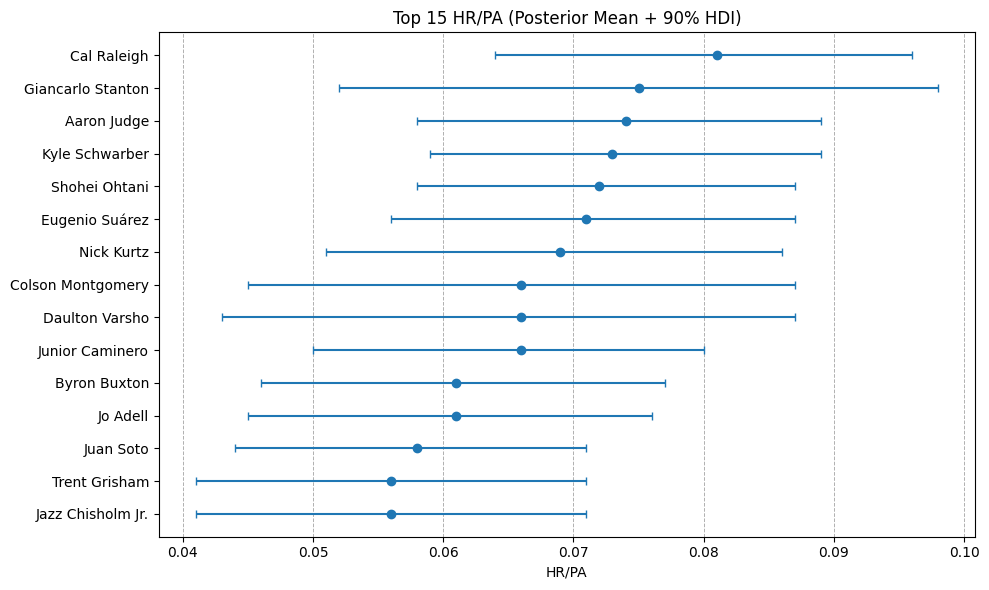

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_top15_interval(top15, title=None, x_label="Rate", lg_rate=None):
    df = top15.copy()

    # Clean labels like "p[Michael Toglia]" -> "Michael Toglia"
    df["player_clean"] = (
        df["player"].astype(str)
          .str.replace(r"^p\[(.*)\]$", r"\1", regex=True)
    )

    # Put highest mean at top of chart
    df = df.sort_values("mean", ascending=True).reset_index(drop=True)

    y = np.arange(len(df))
    x = df["mean"].to_numpy()
    xerr = np.vstack([
        (df["mean"] - df["hdi_5%"]).to_numpy(),
        (df["hdi_95%"] - df["mean"]).to_numpy()
    ])

    if title is None:
        title = df.attrs.get("label", "Top 15 (Posterior Mean + 90% HDI)")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.errorbar(x, y, xerr=xerr, fmt="o", capsize=3, linestyle="none")

    ax.set_yticks(y)
    ax.set_yticklabels(df["player_clean"])
    ax.set_xlabel(x_label)
    ax.set_title(title)
    ax.grid(True, axis="x", linestyle="--", linewidth=0.7)

    if lg_rate is not None:
        ax.axvline(lg_rate, linewidth=1)

    plt.tight_layout()
    plt.show()


# HR plot
plot_top15_interval(
    top15_hr,
    title="Top 15 HR/PA (Posterior Mean + 90% HDI)",
    x_label="HR/PA"
)

In [ ]:
print("Top 15 HR/PA (posterior mean + 90% interval):")
display(top15_hr)

Top 15 HR/PA (posterior mean + 90% interval):


,player,mean,hdi_5%,hdi_95%
0,p[Cal Raleigh],0.081,0.064,0.096
1,p[Giancarlo Stanton],0.075,0.052,0.098
2,p[Aaron Judge],0.074,0.058,0.089
3,p[Kyle Schwarber],0.073,0.059,0.089
4,p[Shohei Ohtani],0.072,0.058,0.087
5,p[Eugenio Suárez],0.071,0.056,0.087
6,p[Nick Kurtz],0.069,0.051,0.086
7,p[Junior Caminero],0.066,0.050,0.080
8,p[Colson Montgomery],0.066,0.045,0.087
9,p[Daulton Varsho],0.066,0.043,0.087


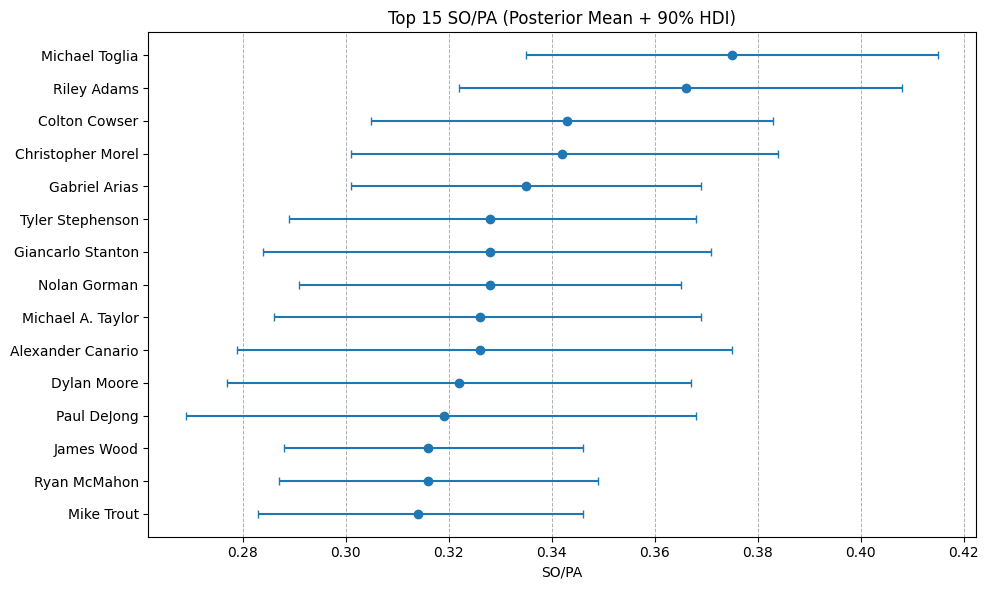

In [ ]:
# SO plot
plot_top15_interval(
    top15_so,
    title="Top 15 SO/PA (Posterior Mean + 90% HDI)",
    x_label="SO/PA"
)


In [ ]:
print("Top 15 SO/PA (posterior mean + 90% interval):")
display(top15_so)

Top 15 SO/PA (posterior mean + 90% interval):


,player,mean,hdi_5%,hdi_95%
0,p[Michael Toglia],0.375,0.335,0.415
1,p[Riley Adams],0.366,0.322,0.408
2,p[Colton Cowser],0.343,0.305,0.383
3,p[Christopher Morel],0.342,0.301,0.384
4,p[Gabriel Arias],0.335,0.301,0.369
5,p[Tyler Stephenson],0.328,0.289,0.368
6,p[Nolan Gorman],0.328,0.291,0.365
7,p[Giancarlo Stanton],0.328,0.284,0.371
8,p[Michael A. Taylor],0.326,0.286,0.369
9,p[Alexander Canario],0.326,0.279,0.375


## The key Bayesian idea

The model shrinks noisy player rates toward the league-wide average. Players with **small sample sizes (low PA)** get **more shrinkage** and **wider uncertainty intervals** (less confidence). Players with **large sample sizes (high PA)** get **less shrinkage** and **tighter intervals** (more confidence).

## How this helps the Los Angeles Dodgers in real life

**1) Better player evaluation (avoiding the small-sample trap)**  
Early-season stats can be misleading. If a hitter pops **6 HR in 60 PA** in April, the raw rate looks elite, but it could be a hot streak. The Bayesian estimate effectively says, “It might be real, but uncertainty is high,” and it pulls the estimate toward a reasonable baseline until the player accumulates more PA. For the Dodgers, this means fewer decisions driven by short-term noise.

**2) Projections you can actually trust**  
You’re estimating each player’s *latent* true skill rates like **HR/PA (power)**, **SO/PA (contact risk)**, and **BB/PA (plate discipline)**. Those become cleaner inputs for rest-of-season projections, lineup optimization (matchups/platoons), and identifying trade targets (buy-low vs sell-high).

**3) Decision-making with risk, not just averages**  
The Dodgers don’t just care about the highest mean—they care about downside and uncertainty. Bayesian outputs make it easy to separate **floor** from **ceiling**: use the **lower bound (HDI p5)** for a conservative floor, use **interval width (p95 − p5)** as a quick “risk” read, and treat a tight interval as stronger evidence the signal is real. Two hitters might have similar mean HR/PA, but the one with a tighter interval is a safer playoff bet, while the other might be boom-or-bust.

**4) Scouting and player development targeting**  
Some skills stabilize faster than others: **K% and BB%** typically firm up sooner than **HR%** in small samples. That means you can flag likely real changes earlier—like contact regression when posterior K-rate shifts up, or plate-discipline improvement when posterior BB-rate shifts up—and focus coaching time where change is more likely real, not random.

**5) “How many PA until we believe it?”**  
A super practical front-office use is turning gut-feel arguments into clear thresholds. You can ask: “How many more PA until we’re 80% confident his HR/PA is above league average?” That directly supports calls like whether to promote him (AAA → MLB), move him up the lineup, or stick with him through a slump.


**6) Opponent prep and game strategy**  
You can do the same modeling for pitchers (K-rate, BB-rate, HR/PA allowed) and feed the probabilities into pinch-hit choices, plate-approach decisions (take vs swing), and bullpen usage—while still accounting for uncertainty so you don’t overreact to tiny samples.

## What I would deliver as a quant analyst (practical outputs)

**A) Per-player table**  
For each player: posterior mean, a 90% interval (HDI), and a simple confidence grade based on interval width (narrow = higher confidence).

**B) Rankings that match real decisions**  
Ceiling (sort by mean), floor (sort by HDI p5), and risk (sort by interval width).

**C) A live dashboard**  
A dashboard that updates daily as PA/IP updates, highlighting **credible movement (real change)** rather than noise-driven movement.

## One opinion

If I’m building this for hitters, I’d model **Bayesian K% and BB% first** because they stabilize earlier, then add **HR/PA** since it’s more volatile. K/BB tends to be more predictive sooner with fewer plate appearances.


## Quick translation of the table

If a line shows `mean = 0.075`, that’s an estimated true HR rate of about **7.5 HR per 100 PA**. If `hdi_5% = 0.054` and `hdi_95% = 0.100`, that means “I’m about 90% sure his true HR rate is between **5.4% and 10.0%**.” A wider interval generally means less certainty, usually because the player has fewer PA or the signal is noisier.


**Forecast HRs over the next 200 PA (posterior predictive)**

In [ ]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

def forecast_from_idata(idata, players, league_rate=None, future_n=200, q_low=0.05, q_high=0.95, label="HR"):
    """
    idata: PyMC InferenceData with posterior['p'] indexed by coords 'player'
    players: 1-D list/array of player names in the same order as the model coords
    league_rate: if you computed it earlier (sum(y)/sum(n)), pass it. If None, we skip prob>league.
    """

    # p dims: (chain, draw, player) OR (player, chain, draw) depending on stacking; we normalize via stack
    p_xr = idata.posterior["p"].stack(sample=("chain", "draw"))  # dims: player x sample
    p_vals = p_xr.values  # shape: (num_players, num_samples)

    # rate summaries
    p_mean = p_vals.mean(axis=1)
    p_p5   = np.quantile(p_vals, q_low, axis=1)
    p_p95  = np.quantile(p_vals, q_high, axis=1)

    # prob above league avg (optional)
    if league_rate is None:
        pr_above = np.full(len(players), np.nan)
    else:
        pr_above = (p_vals > league_rate).mean(axis=1)

    # posterior predictive: events in next future_n
    future_sims = rng.binomial(n=future_n, p=p_vals)  # (num_players, num_samples)
    fut_mean = future_sims.mean(axis=1)
    fut_p5   = np.quantile(future_sims, q_low, axis=1)
    fut_p95  = np.quantile(future_sims, q_high, axis=1)

    return pd.DataFrame({
        "player": np.array(players, dtype=str),
        f"{label}_rate_mean": p_mean,
        f"{label}_rate_p5": p_p5,
        f"{label}_rate_p95": p_p95,
        f"Pr_{label}_rate_gt_lg": pr_above,
        f"{label}_next{future_n}_mean": fut_mean,
        f"{label}_next{future_n}_p5": fut_p5,
        f"{label}_next{future_n}_p95": fut_p95,
    })


players_hr = coords_hr["player"]
players_so = coords_so["player"]

# league rates from the arrays you used in each model
league_hr = y_hr.sum() / n_hr.sum()
league_so = y_so.sum() / n_so.sum()

future_pa = 200

forecast_hr = forecast_from_idata(
    idata_hr, players_hr, league_rate=league_hr, future_n=future_pa, label="HR"
)

forecast_so = forecast_from_idata(
    idata_so, players_so, league_rate=league_so, future_n=future_pa, label="SO"
)

top15_forecast_hr = forecast_hr.sort_values(f"HR_next{future_pa}_mean", ascending=False).head(15)
top15_forecast_so = forecast_so.sort_values(f"SO_next{future_pa}_mean", ascending=False).head(15)

In [ ]:
print("\nTOP 15 HR forecast (next 200 PA):")
display(top15_forecast_hr)


TOP 15 HR forecast (next 200 PA):


,player,HR_rate_mean,HR_rate_p5,HR_rate_p95,Pr_HR_rate_gt_lg,HR_next200_mean,HR_next200_p5,HR_next200_p95
10,Cal Raleigh,0.080557,0.064923,0.097299,1.000000,16.084625,9.0,23.0
293,Giancarlo Stanton,0.075489,0.053270,0.100292,1.000000,15.079750,8.0,23.0
23,Aaron Judge,0.073986,0.059009,0.090312,1.000000,14.756375,9.0,22.0
4,Kyle Schwarber,0.073440,0.058960,0.089170,1.000000,14.708250,8.0,22.0
2,Shohei Ohtani,0.072040,0.057843,0.087172,1.000000,14.435625,8.0,21.0
34,Eugenio Suárez,0.070807,0.055820,0.087281,1.000000,14.165000,8.0,21.0
151,Nick Kurtz,0.068657,0.051776,0.086666,1.000000,13.721000,7.0,21.0
288,Colson Montgomery,0.066211,0.046386,0.088922,0.998625,13.286500,7.0,21.0
41,Junior Caminero,0.065628,0.051102,0.081530,1.000000,13.088125,7.0,20.0
297,Daulton Varsho,0.065506,0.044721,0.089446,0.997500,13.061125,6.0,21.0


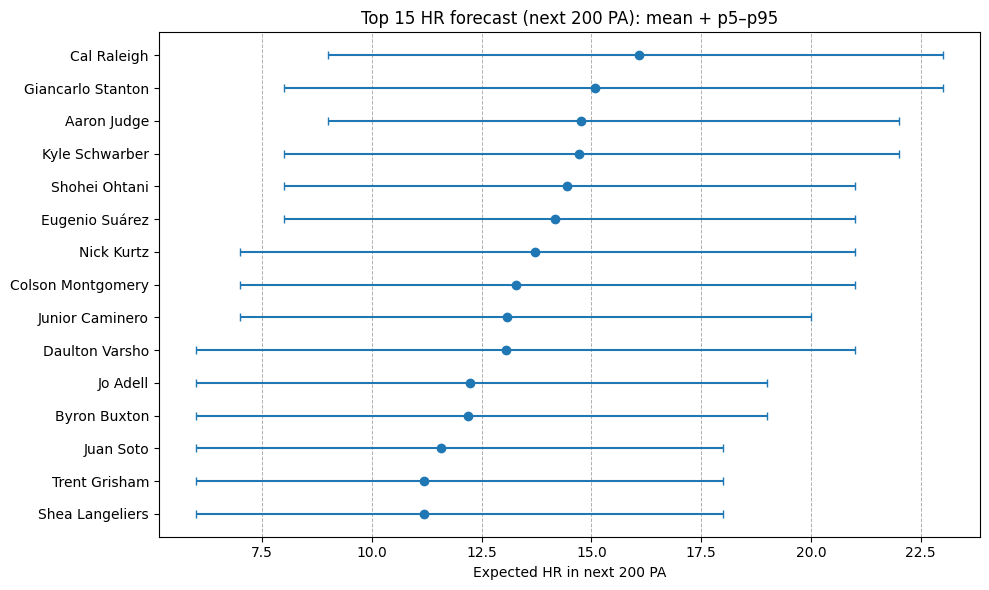

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_forecast_forest(
    df_top,
    label="HR",
    future_n=200,
    title=None,
):
    """
    df_top: e.g., top15_forecast_hr or top15_forecast_so
            must include:
              player,
              {label}_next{future_n}_mean,
              {label}_next{future_n}_p5,
              {label}_next{future_n}_p95
    """

    mean_col = f"{label}_next{future_n}_mean"
    p5_col   = f"{label}_next{future_n}_p5"
    p95_col  = f"{label}_next{future_n}_p95"

    d = df_top.copy()

    # Clean names like "p[Michael Toglia]" -> "Michael Toglia" (if present)
    d["player_clean"] = (
        d["player"].astype(str)
          .str.replace(r"^p\[(.*)\]$", r"\1", regex=True)
    )

    # Sort so highest mean is at top
    d = d.sort_values(mean_col, ascending=True).reset_index(drop=True)

    y = np.arange(len(d))
    x = d[mean_col].to_numpy()

    xerr = np.vstack([
        (d[mean_col] - d[p5_col]).to_numpy(),
        (d[p95_col] - d[mean_col]).to_numpy(),
    ])

    if title is None:
        title = f"Top {len(d)} {label} forecast (next {future_n} PA): mean + p5–p95"

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.errorbar(x, y, xerr=xerr, fmt="o", capsize=3, linestyle="none")

    ax.set_yticks(y)
    ax.set_yticklabels(d["player_clean"])
    ax.set_xlabel(f"Expected {label} in next {future_n} PA")
    ax.set_title(title)
    ax.grid(True, axis="x", linestyle="--", linewidth=0.7)

    plt.tight_layout()
    plt.show()


# ---- use it ----
plot_forecast_forest(top15_forecast_hr, label="HR", future_n=future_pa)



## Home Run Forecast Columns (Next 200 PA)

- **HR_rate_mean**= your best estimate of the player’s true HR% (HR/PA), shrunk for sample size.

- **HR_rate_p5..p95** = uncertainty band for that true HR%.

- **Pr_HR_rate_gt_lg** = “How confident are we he’s above league average power?”

- **HR_next200_mean** = expected HRs over next 200 PA.

- **HR_next200_p5..p95** = “reasonable range” of HR outcomes over next 200 PA.

## What these numbers mean (HR and PA)

The table is estimating each player’s true home run rate per plate appearance (HR/PA), and then using that uncertainty to forecast how many home runs they might hit in a future sample of 200 PA. HR_rate_mean is the model’s best estimate of the player’s true HR rate. For example, Cal Raleigh at 0.0806 means the model thinks his underlying rate is about 8.1 HR per 100 PA.


If you want to compare players in a decision-making context, you can treat the posterior mean as a simple “expected level,” the 5th percentile (p5) as a practical “lower bound,” and the interval width (p95 − p5) as a quick read on uncertainty or “risk.” Two players can have similar means, but the one with the higher p5 is a safer bet, while the one with the wider interval is more boom-or-bust.

In [ ]:


print("\nTOP 15 SO forecast (next 200 PA):")
display(top15_forecast_so)



TOP 15 SO forecast (next 200 PA):


,player,SO_rate_mean,SO_rate_p5,SO_rate_p95,Pr_SO_rate_gt_lg,SO_next200_mean,SO_next200_p5,SO_next200_p95
251,Michael Toglia,0.374882,0.334846,0.415975,1.00000,75.015625,61.0,89.0
287,Riley Adams,0.365775,0.323364,0.410639,1.00000,73.284625,59.0,88.0
237,Colton Cowser,0.343011,0.305097,0.382994,1.00000,68.596375,55.0,82.0
273,Christopher Morel,0.342337,0.301087,0.384179,1.00000,68.368125,55.0,82.0
158,Gabriel Arias,0.335083,0.301179,0.370008,1.00000,67.034375,54.0,80.0
214,Nolan Gorman,0.328356,0.291553,0.365770,1.00000,65.728125,53.0,79.0
247,Tyler Stephenson,0.327954,0.289045,0.367893,1.00000,65.683500,52.0,80.0
293,Giancarlo Stanton,0.327530,0.284854,0.371358,1.00000,65.513875,52.0,80.0
264,Michael A. Taylor,0.326422,0.285962,0.368603,1.00000,65.300500,52.0,79.0
314,Alexander Canario,0.325603,0.279676,0.374995,1.00000,65.064125,51.0,80.0


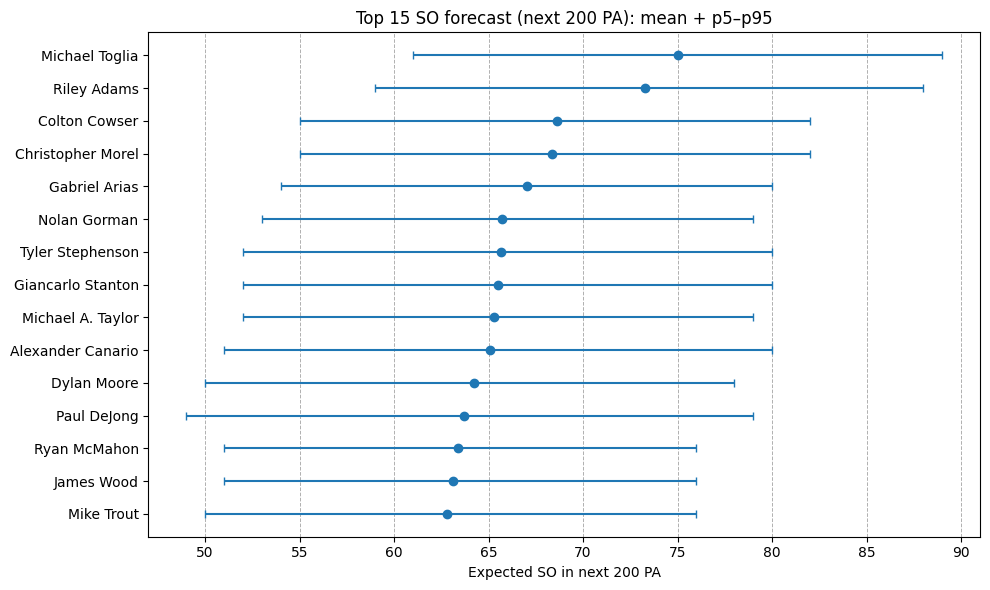

In [ ]:
plot_forecast_forest(top15_forecast_so, label="SO", future_n=future_pa)


## Strikeout Forecast Columns (Next 200 PA)

- **SO_rate_mean** = your best estimate of the player’s true K% (**SO/PA**), shrunk for sample size.  
- **SO_rate_p5..p95** = uncertainty band for that true K%.  
- **Pr_SO_rate_gt_lg** = “How confident are we he’s above league-average strikeout rate?”  
- **SO_next200_mean** = expected strikeouts over the next **200 PA**.  
- **SO_next200_p5..p95** = “reasonable range” of strikeout outcomes over the next **200 PA**.

### What these numbers mean (SO and PA)

This table estimates each player’s true strikeout rate per plate appearance (**SO/PA**), then uses that uncertainty to forecast how many strikeouts they might have in a future sample of **200 PA**. **SO_rate_mean** is the model’s best estimate of the player’s underlying strikeout rate. For example, a value of **0.3744** means the model thinks the player strikes out about **37.4 times per 100 PA**.

If you want to compare players in a decision-making context, you can treat the **posterior mean** as a simple “expected level,” the **5th percentile (p5)** as a practical “lower bound,” and the **interval width (p95 − p5)** as a quick read on uncertainty or “risk.” Two players can have similar means, but the one with the **lower p5** is a safer bet for fewer strikeouts, while the one with the **wider interval** is more boom-or-bust.

## Conclusion

### Results (what the project delivered)
This project produced Bayesian estimates of each player’s underlying rate for key outcomes like **HR/PA** (power) and **SO/PA** (strikeout risk). Instead of relying on raw small-sample rates, the model outputs a **posterior mean** (best estimate) plus a **90% credible interval (HDI)**, which makes uncertainty explicit. Using posterior draws, I also generated forward-looking forecasts such as **expected HR (or SO) over the next 200 PA**, along with a realistic range (p5–p95). The end result is a Attachment-friendly table and a visualization (dot + interval plot) that ranks players by expected level while showing risk/uncertainty.

### What I learned / key takeaways
The biggest takeaway is how useful **partial pooling (shrinkage)** is in sports-style rate problems. Players with fewer plate appearances produce noisier observed rates, and the Bayesian model automatically pulls those rates toward a league baseline while still allowing true outliers to stand out as data accumulates. I also learned that communicating results is easier when everything is expressed in decision-ready terms: **“expected outcomes over the next 200 PA” + “uncertainty band”** is clearer than only reporting a point estimate. Finally, comparing players becomes more honest: two players can have similar posterior means but very different risk profiles depending on interval width.

### What didn’t work well
A few things limited the model and explain why some outputs can look less stable or less impressive than expected:

- **Small sample volatility still exists:** even with shrinkage, players near the minimum PA cutoff can have wide intervals, so rankings can be sensitive for borderline cases.
- **Single-season snapshot:** using one season of counts can miss longer-term skill, injuries, role changes, and true aging effects.
- **No covariates yet:** the model treats each player as “just a rate,” without accounting for context like park effects, handedness, lineup protection, pitcher quality faced, or batted-ball profile—so differences that are real may get partially absorbed as noise.
- **Simple hierarchical structure:** the Beta–Binomial partial pooling is strong and interpretable, but it assumes players come from one shared league distribution; that can underfit subgroups (e.g., power hitters vs contact hitters) unless expanded.

### How I would improve it next
There are several clear upgrades that would make the model more accurate and more useful:

1) **Multi-season / time dynamics**  
   Extend to multiple seasons or rolling windows and model player rates over time (e.g., dynamic priors), which would better separate true skill from short-term variance.

2) **Richer hierarchy (more realistic pooling)**  
   Add group-level structure (e.g., by position, handedness, age buckets, or batted-ball archetype) so shrinkage happens toward the right peer group, not only the overall league.

3) **Add covariates (explainable context)**  
   Include predictors like ballpark factors, opponent quality, role (starter vs platoon), and batter profile features to reduce unexplained variance and improve forecast realism.

4) **Posterior predictive checks and calibration**  
   Run formal PPCs to verify the model reproduces observed distributions and calibrate interval coverage (e.g., whether 90% intervals contain outcomes about 90% of the time).

5) **Decision-focused outputs**  
   Add thresholds like “PA needed to reach 80% confidence above league average” and produce “floor/ceiling/risk” rankings for roster decisions, lineup optimization, and scouting reports.

### Final takeaway
Overall, the project demonstrates how Bayesian modeling improves evaluation and forecasting by replacing raw-rate overreactions with **probabilistic estimates**: a best estimate, a credible range, and a forecast distribution. The model is already useful for ranking and risk-aware comparisons, and the next improvements would focus on adding context (covariates), better subgroup pooling, and time dynamics to make forecasts more accurate and more actionable.
